# RetainIQ — Phase 5.3: Segment Profiling & Customer Behavior

## Objective

I will turn the cluster IDs into interpretable customer profiles using:

- value
- tenure
- monthly charge
- satisfaction
- service adoption
- contract
- payment method
- internet type
- churn rate
- revenue at risk

## 1. Connect to MySQL

In [1]:
from getpass import getpass
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
from mysql.connector import Error

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

MYSQL_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "retainiq_user",
    "password": getpass("Enter MySQL password for retainiq_user: "),
    "database": "retainiq",
}

def get_connection():
    return mysql.connector.connect(**MYSQL_CONFIG)

def run_query(query, params=None):
    connection = None
    cursor = None
    try:
        connection = get_connection()
        cursor = connection.cursor(dictionary=True)
        cursor.execute(query, params or ())
        return pd.DataFrame(cursor.fetchall())
    except Error as exc:
        raise RuntimeError(f"MySQL query failed: {exc}") from exc
    finally:
        if cursor:
            cursor.close()
        if connection and connection.is_connected():
            connection.close()

print("MySQL segmentation connection is ready.")

MySQL segmentation connection is ready.


## 2. Pull Customer Profile Data

In [2]:
query = """
SELECT
    f.customer_id,
    f.tenure_months,
    f.monthly_charge,
    f.total_revenue,
    f.satisfaction_score,
    f.cltv,
    f.churn_label,
    f.customer_status,
    d.age,
    a.number_of_referrals,
    a.offer,
    a.contract,
    a.payment_method,
    s.internet_type,
    s.premium_tech_support,
    s.online_security,
    s.online_backup,
    s.device_protection_plan,
    s.streaming_tv,
    s.streaming_movies,
    s.streaming_music,
    s.unlimited_data,
    s.phone_service
FROM fact_customer_status f
JOIN dim_demographics d ON f.customer_id = d.customer_id
JOIN dim_account a ON f.customer_id = a.customer_id
JOIN dim_services s ON f.customer_id = s.customer_id;
"""

profile_df = run_query(query)

for column in [
    "tenure_months",
    "monthly_charge",
    "total_revenue",
    "satisfaction_score",
    "cltv",
    "age",
    "number_of_referrals"
]:
    profile_df[column] = pd.to_numeric(
        profile_df[column],
        errors="coerce"
    )

service_columns = [
    "phone_service",
    "premium_tech_support",
    "online_security",
    "online_backup",
    "device_protection_plan",
    "streaming_tv",
    "streaming_movies",
    "streaming_music",
    "unlimited_data"
]

for column in service_columns:
    profile_df[f"{column}_flag"] = (
        profile_df[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )

profile_df["service_count"] = profile_df[
    [f"{column}_flag" for column in service_columns]
].sum(axis=1)

print(f"Loaded profile dataset: {len(profile_df):,} customers")

Loaded profile dataset: 7,043 customers


## 3. Load Cluster Assignments

In [3]:
assignment_path = Path("../outputs/customer_segment_assignments.csv")

if not assignment_path.exists():
    raise FileNotFoundError(
        "Run Notebook 5.2 before running this notebook."
    )

assignments = pd.read_csv(assignment_path)

profile_df = profile_df.merge(
    assignments,
    on="customer_id",
    how="inner"
)

assert len(profile_df) == 7043
assert profile_df["segment_id"].notna().all()

print("PASS — all customers have segment assignments.")

PASS — all customers have segment assignments.


## 4. Segment Size Profile

In [4]:
segment_size = (
    profile_df["segment_id"]
    .value_counts()
    .sort_index()
    .rename("customers")
    .reset_index()
)

segment_size["share_pct"] = (
    segment_size["customers"]
    / len(profile_df)
    * 100
).round(2)

segment_size

,segment_id,customers,share_pct
0,0,3226,45.800
1,1,1557,22.110
2,2,2260,32.090


## 5. Core Segment Profile

In [5]:
segment_profile = (
    profile_df.groupby("segment_id")
    .agg(
        customers=("customer_id", "count"),
        avg_tenure_months=("tenure_months", "mean"),
        avg_monthly_charge=("monthly_charge", "mean"),
        avg_total_revenue=("total_revenue", "mean"),
        total_revenue=("total_revenue", "sum"),
        avg_cltv=("cltv", "mean"),
        avg_satisfaction=("satisfaction_score", "mean"),
        avg_age=("age", "mean"),
        avg_referrals=("number_of_referrals", "mean"),
        avg_service_count=("service_count", "mean")
    )
    .round(2)
)

segment_profile

,customers,avg_tenure_months,avg_monthly_charge,avg_total_revenue,total_revenue,avg_cltv,avg_satisfaction,avg_age,avg_referrals,avg_service_count
segment_id,,,,,,,,,,
0,3226,15.740,69.780,"1,415.230","4,565,523.120","4,013.450",2.810,47.760,0.930,3.770
1,1557,30.800,21.530,"1,441.450","2,244,335.560","4,371.240",3.860,42.840,2.190,1.050
2,2260,57.240,87.390,"6,443.040","14,561,273.010","4,972.510",3.450,47.250,3.240,6.270


## 6. Churn and Revenue-at-Risk Profile

In [6]:
retention_rows = []

for segment_id, group in profile_df.groupby("segment_id"):
    churn_mask = group["churn_label"].eq("Yes")

    retention_rows.append({
        "segment_id": segment_id,
        "churned_customers": int(churn_mask.sum()),
        "churn_rate_pct": float(churn_mask.mean() * 100),
        "revenue_at_risk": float(
            group.loc[churn_mask, "total_revenue"].sum()
        )
    })

profile_retention = (
    pd.DataFrame(retention_rows)
    .set_index("segment_id")
    .round(2)
)

profile_retention

,churned_customers,churn_rate_pct,revenue_at_risk
segment_id,,,
0,1516,46.990,"1,944,581.190"
1,110,7.060,"42,982.020"
2,243,10.750,"1,696,896.610"


## 7. Contract Mix

In [7]:
contract_mix = pd.crosstab(
    profile_df["segment_id"],
    profile_df["contract"],
    normalize="index"
).mul(100).round(2)

contract_mix

contract,Month-to-Month,One Year,Two Year
segment_id,,,
0,85.680,9.490,4.840
1,33.080,24.660,42.260
2,14.650,38.050,47.300


## 8. Internet Type Mix

In [8]:
internet_mix = pd.crosstab(
    profile_df["segment_id"],
    profile_df["internet_type"],
    normalize="index"
).mul(100).round(2)

internet_mix

internet_type,Cable,DSL,Fiber Optic,No Internet Service
segment_id,,,,
0,15.870,30.190,53.840,0.090
1,0.960,1.220,0.000,97.820
2,13.410,29.160,57.430,0.000


## 9. Payment Method Mix

In [9]:
payment_mix = pd.crosstab(
    profile_df["segment_id"],
    profile_df["payment_method"],
    normalize="index"
).mul(100).round(2)

payment_mix

payment_method,Bank Withdrawal,Credit Card,Mailed Check
segment_id,,,
0,65.960,27.990,6.040
1,28.970,61.720,9.310
2,58.850,39.160,1.990


## 10. Service Adoption by Segment

In [10]:
service_mix = (
    profile_df.groupby("segment_id")[
        [f"{column}_flag" for column in service_columns]
    ]
    .mean()
    .mul(100)
    .round(2)
)

service_mix

,phone_service_flag,premium_tech_support_flag,online_security_flag,online_backup_flag,device_protection_plan_flag,streaming_tv_flag,streaming_movies_flag,streaming_music_flag,unlimited_data_flag
segment_id,,,,,,,,,
0,84.870,22.350,22.600,28.610,27.590,35.990,35.680,33.510,85.460
1,98.460,1.220,1.160,0.770,0.900,0.190,0.060,0.060,2.120
2,92.480,57.700,56.280,66.110,67.170,68.270,69.910,62.210,86.500


## 11. Average CLTV by Segment

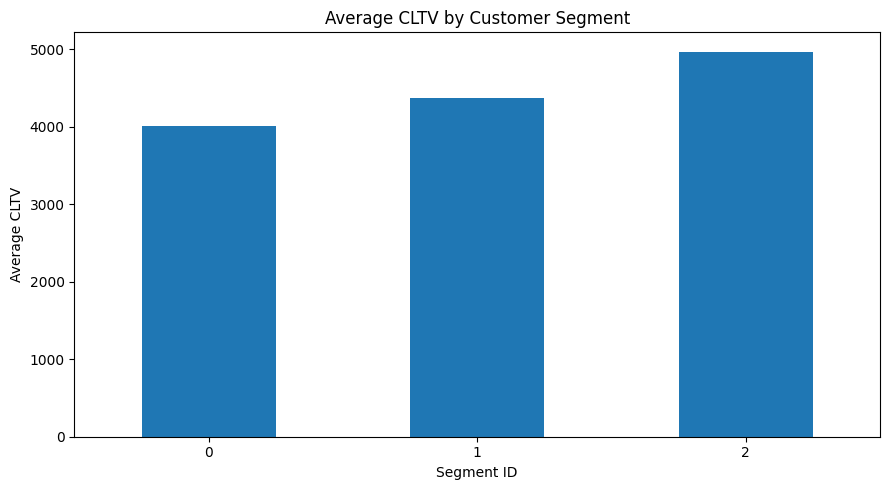

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
segment_profile["avg_cltv"].plot(kind="bar", ax=ax)
ax.set_title("Average CLTV by Customer Segment")
ax.set_xlabel("Segment ID")
ax.set_ylabel("Average CLTV")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Churn Rate by Segment

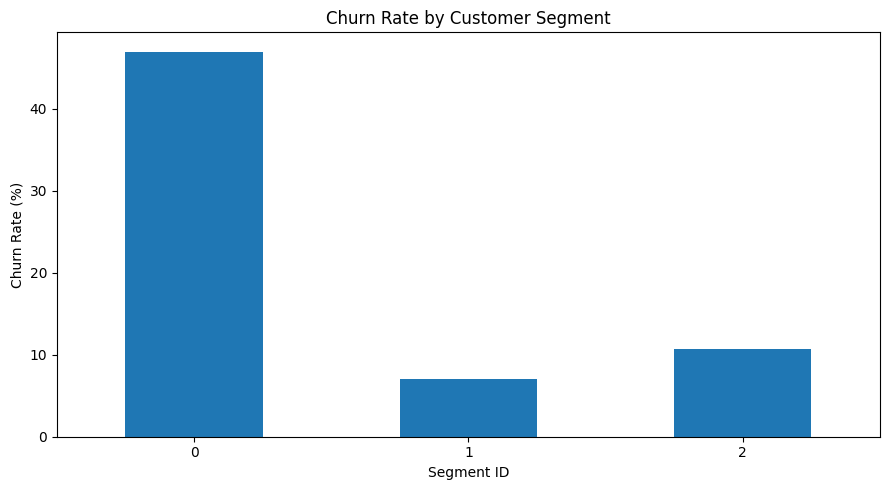

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
profile_retention["churn_rate_pct"].plot(kind="bar", ax=ax)
ax.set_title("Churn Rate by Customer Segment")
ax.set_xlabel("Segment ID")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Segment Value vs Churn

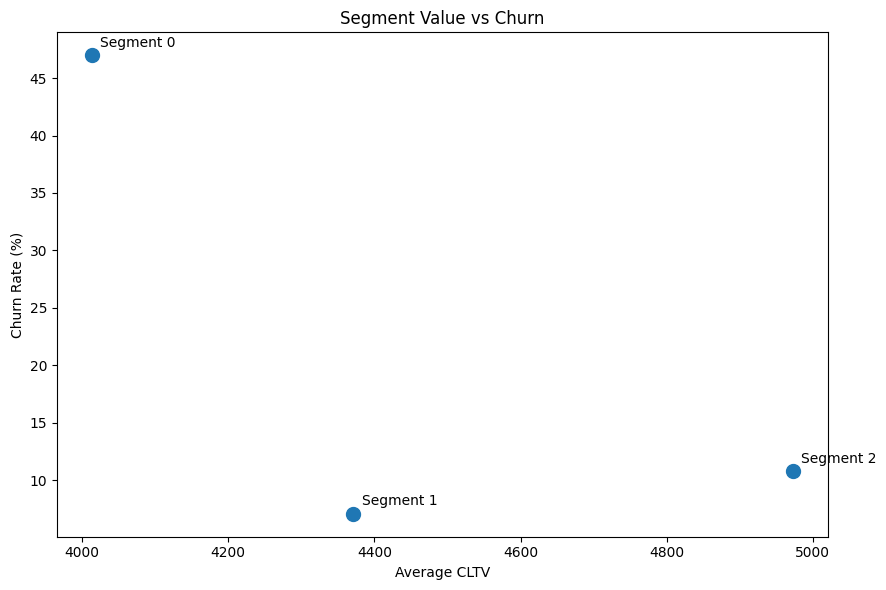

In [13]:
plot_df = segment_profile.join(
    profile_retention[["churn_rate_pct"]]
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    plot_df["avg_cltv"],
    plot_df["churn_rate_pct"],
    s=100
)

for segment_id, row in plot_df.iterrows():
    ax.annotate(
        f"Segment {segment_id}",
        (row["avg_cltv"], row["churn_rate_pct"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.set_title("Segment Value vs Churn")
ax.set_xlabel("Average CLTV")
ax.set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

## 14. Combine Segment Metrics

In [14]:
combined_profile = (
    segment_profile
    .join(profile_retention)
    .join(
        segment_size.set_index("segment_id")["share_pct"]
    )
)

combined_profile

,customers,avg_tenure_months,avg_monthly_charge,avg_total_revenue,total_revenue,avg_cltv,avg_satisfaction,avg_age,avg_referrals,avg_service_count,churned_customers,churn_rate_pct,revenue_at_risk,share_pct
segment_id,,,,,,,,,,,,,,
0,3226,15.740,69.780,"1,415.230","4,565,523.120","4,013.450",2.810,47.760,0.930,3.770,1516,46.990,"1,944,581.190",45.800
1,1557,30.800,21.530,"1,441.450","2,244,335.560","4,371.240",3.860,42.840,2.190,1.050,110,7.060,"42,982.020",22.110
2,2260,57.240,87.390,"6,443.040","14,561,273.010","4,972.510",3.450,47.250,3.240,6.270,243,10.750,"1,696,896.610",32.090


## 15. Export Segment Profile Artifacts

In [15]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

combined_profile.to_csv(
    output_dir / "segment_profile_summary.csv"
)

contract_mix.to_csv(
    output_dir / "segment_contract_mix.csv"
)

internet_mix.to_csv(
    output_dir / "segment_internet_mix.csv"
)

payment_mix.to_csv(
    output_dir / "segment_payment_mix.csv"
)

service_mix.to_csv(
    output_dir / "segment_service_mix.csv"
)

print("Segment profiling artifacts exported.")

Segment profiling artifacts exported.


## 16. Interpretation Rule

I will inspect the actual profile metrics before assigning business-facing names.

The labels should describe observed differences in value, behavior, service adoption, retention,
and revenue exposure.

# Phase 5.3 Conclusion

I transformed anonymous cluster IDs into detailed customer profiles and exported the segment
summary for the final retention layer.

**Next:** retention profiles and MySQL publishing.